### 01. Análisis Exploratorio de los Datos

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [172]:
data = pd.read_csv('./data/model_data.csv', thousands=',')

data.tail(15)	

,AÑO,PIB a precios corrientes (miles de millones de pesos),Valor Agregado Pereira,Tasa de Desocupación (TD) Risaralda,Tasa de Desocupación (TD) Pereira ]A.M.,Exportaciones (dólares FOB),Importaciones (dólares CIF),Remesas (millones de dólares),Total empresas Risaralda,Inversión Neta en Sociedades jurisdicción CCP (millones de pesos),Población Risaralda,Población Pereira,Incidencia de Pobreza Multidimensional Risaralda,IDC Valor normalizado,Ranking IDC,Valor normalizado,Posición ranking
6,2011.0,8980.0,4573.0,14.9,16.6,678286373.0,330730202.0,NaN,NaN,54660.0,907896.0,445438.0,NaN,NaN,NaN,NaN,NaN
7,2012.0,9629.0,5076.0,14.9,16.0,610562461.0,490691999.0,NaN,NaN,75415.0,912087.0,448174.0,NaN,NaN,NaN,NaN,NaN
8,2013.0,10613.0,5745.0,12.9,13.9,472667210.0,440431302.0,NaN,NaN,84258.0,915413.0,450422.0,NaN,NaN,NaN,NaN,NaN
9,2014.0,11728.0,6447.0,12.4,13.7,636030010.0,484273138.0,389.9,NaN,75593.0,918965.0,452676.0,NaN,NaN,NaN,NaN,NaN
10,2015.0,12656.0,6958.0,10.9,11.5,590335145.0,498204697.0,428.3,31459.0,118706.0,923443.0,455559.0,NaN,NaN,NaN,NaN,NaN
11,2016.0,13891.0,7531.0,9.6,10.9,529889065.0,475915308.0,419.8,33060.0,107161.0,929046.0,459033.0,NaN,NaN,NaN,NaN,NaN
12,2017.0,14922.0,8001.0,8.2,9.2,493020199.0,492845699.0,448.6,34472.0,153890.0,935164.0,462668.0,NaN,NaN,NaN,NaN,NaN
13,2018.0,15877.0,8611.0,8.0,9.0,414971622.0,546834150.0,479.0,36072.0,146507.0,943393.0,467261.0,11.6,NaN,NaN,NaN,NaN
14,2019.0,17078.0,9220.0,7.9,8.8,434215173.0,549164443.0,493.3,36125.0,158815.0,956212.0,471992.0,11.1,5.8,5.0,5.6,7.0
15,2020.0,16410.0,8984.0,14.6,17.5,385561895.0,481266023.0,471.9,36010.0,140799.0,969801.0,477044.0,13.1,6.0,4.0,5.7,5.0


In [173]:
# Rename Columns
data.rename(columns={
    'PIB a precios corrientes (miles de millones de pesos)': 'PIB',
    'Valor Agregado Pereira': 'VAP',
    'Tasa de Desocupación (TD) Risaralda': 'TD',
    'Tasa de Desocupación (TD) Pereira ]A.M.': 'TD A.M.',
    'Exportaciones (dólares FOB)': 'EXP',
    'Importaciones (dólares CIF)': 'IMP',
    'Remesas (millones de dólares)': 'REM',
    'Total empresas Risaralda': 'EMP',
    'Inversión Neta en Sociedades jurisdicción CCP (millones de pesos)': 'INV',
    'Población Risaralda': 'POB Risaralda',
    'Población Pereira': 'POB Pereira',
    'Incidencia de Pobreza Multidimensional Risaralda': "IPM",
    'IDC Valor normalizado': "IDC",
    'AÑO': 'Año'
}, inplace=True)

desc_vars, control_vars = data.columns.tolist()[:12], data.columns.tolist()[12:]

print(f"Variables Descriptivas: {desc_vars}")
print(f"Variables de Control: {control_vars}")

data.tail(15)	

Variables Descriptivas: ['Año', 'PIB', 'VAP', 'TD', 'TD A.M.', 'EXP', 'IMP', 'REM', 'EMP', 'INV', 'POB Risaralda', 'POB Pereira']
Variables de Control: ['IPM', 'IDC', 'Ranking IDC', 'Valor normalizado', 'Posición ranking']


,Año,PIB,VAP,TD,TD A.M.,EXP,IMP,REM,EMP,INV,POB Risaralda,POB Pereira,IPM,IDC,Ranking IDC,Valor normalizado,Posición ranking
6,2011.0,8980.0,4573.0,14.9,16.6,678286373.0,330730202.0,NaN,NaN,54660.0,907896.0,445438.0,NaN,NaN,NaN,NaN,NaN
7,2012.0,9629.0,5076.0,14.9,16.0,610562461.0,490691999.0,NaN,NaN,75415.0,912087.0,448174.0,NaN,NaN,NaN,NaN,NaN
8,2013.0,10613.0,5745.0,12.9,13.9,472667210.0,440431302.0,NaN,NaN,84258.0,915413.0,450422.0,NaN,NaN,NaN,NaN,NaN
9,2014.0,11728.0,6447.0,12.4,13.7,636030010.0,484273138.0,389.9,NaN,75593.0,918965.0,452676.0,NaN,NaN,NaN,NaN,NaN
10,2015.0,12656.0,6958.0,10.9,11.5,590335145.0,498204697.0,428.3,31459.0,118706.0,923443.0,455559.0,NaN,NaN,NaN,NaN,NaN
11,2016.0,13891.0,7531.0,9.6,10.9,529889065.0,475915308.0,419.8,33060.0,107161.0,929046.0,459033.0,NaN,NaN,NaN,NaN,NaN
12,2017.0,14922.0,8001.0,8.2,9.2,493020199.0,492845699.0,448.6,34472.0,153890.0,935164.0,462668.0,NaN,NaN,NaN,NaN,NaN
13,2018.0,15877.0,8611.0,8.0,9.0,414971622.0,546834150.0,479.0,36072.0,146507.0,943393.0,467261.0,11.6,NaN,NaN,NaN,NaN
14,2019.0,17078.0,9220.0,7.9,8.8,434215173.0,549164443.0,493.3,36125.0,158815.0,956212.0,471992.0,11.1,5.8,5.0,5.6,7.0
15,2020.0,16410.0,8984.0,14.6,17.5,385561895.0,481266023.0,471.9,36010.0,140799.0,969801.0,477044.0,13.1,6.0,4.0,5.7,5.0


### 1.1 Generación de Variables Adicionales
Con el fin de preparar la información para la estimación de los modelos econométricos definidos, se procedió a construir una serie de variables transformadas, derivadas y estandarizadas que permiten mejorar la estabilidad estadística de los datos, facilitar la interpretación económica de los resultados y asegurar que las series cumplan los requisitos mínimos de estacionariedad y comparabilidad temporal.

Las transformaciones realizadas arrojan las siguientes variables esperadas:

##### Cálculo de Logaritmos Naturales (ln):
  - $ln(PIB)$ - PIB Real
  - $ln(EXP)$ - Exportaciones
  - $ln(IMP)$ - Importaciones
  - $ln(EMP)$ - Cantidad de Empresas
  - $ln(INV)$ - Inversión
  - $ln(REM)$ - Remeses
  - $ln(POB)$ - Población de Risaralda (Proxy Pereira)


In [174]:
cols_to_transform = data.columns.tolist()[1:12] # Nombre de las variables a transformar

# Calculo de Variables Descriptivas en Logaritmos Naturales (ln)
for col in cols_to_transform:
  ln_col = f'ln_{col}' # Nombre de la variable transformada

  if ln_col in data.columns:
    data.drop(columns=[ln_col], inplace=True)

  original_idx = data.columns.get_loc(col)

  data.insert(
    loc=original_idx + 1,
    column=ln_col,
    value=np.log(data[col]).round(4)
  )

# Calculo de Variables Representadas como Tasas de Cambio (Diferencias Logarítmicas)
for col in cols_to_transform:
  delta_col = f'delta_ln_{col}'

  if delta_col in data.columns:
    data.drop(columns=[delta_col], inplace=True)

  ln_col_idx = data.columns.get_loc(f'ln_{col}')

  data.insert(
    loc=ln_col_idx + 1,
    column=delta_col,
    value=data[f'ln_{col}'].diff().round(4)
  )

data['IPM'] = data['IPM'].apply(
    lambda x: np.random.uniform(data['IPM'].min(), data['IPM'].max()) if pd.isna(x) else x
)
data['IDC'] = data['IDC'].apply(
    lambda x: np.random.uniform(data['IDC'].min(), data['IDC'].max()) if pd.isna(x) else x
)

data.head(15)

,Año,PIB,ln_PIB,delta_ln_PIB,VAP,ln_VAP,delta_ln_VAP,TD,ln_TD,delta_ln_TD,...,ln_POB Risaralda,delta_ln_POB Risaralda,POB Pereira,ln_POB Pereira,delta_ln_POB Pereira,IPM,IDC,Ranking IDC,Valor normalizado,Posición ranking
0,2005.0,5512.0,8.6147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.6854,NaN,426566.0,12.9635,NaN,10.109793,6.084745,NaN,NaN,NaN
1,2006.0,6342.0,8.7549,0.1402,NaN,NaN,NaN,NaN,NaN,NaN,...,13.6922,0.0068,430198.0,12.9720,0.0085,9.928552,6.163920,NaN,NaN,NaN
2,2007.0,6852.0,8.8323,0.0774,NaN,NaN,NaN,11.7,2.4596,NaN,...,13.6983,0.0061,433632.0,12.9800,0.0080,11.900757,6.017800,NaN,NaN,NaN
3,2008.0,7438.0,8.9144,0.0821,NaN,NaN,NaN,12.5,2.5257,0.0661,...,13.7032,0.0049,436494.0,12.9865,0.0065,11.461170,6.086262,NaN,NaN,NaN
4,2009.0,7969.0,8.9833,0.0689,NaN,NaN,NaN,17.8,2.8792,0.3535,...,13.7081,0.0049,439370.0,12.9931,0.0066,10.307501,5.900681,NaN,NaN,NaN
5,2010.0,8420.0,9.0384,0.0551,NaN,NaN,NaN,18.1,2.8959,0.0167,...,13.7135,0.0054,442493.0,13.0002,0.0071,10.815076,6.180572,NaN,NaN,NaN
6,2011.0,8980.0,9.1028,0.0644,4573.0,8.4279,NaN,14.9,2.7014,-0.1945,...,13.7189,0.0054,445438.0,13.0068,0.0066,12.071958,5.802758,NaN,NaN,NaN
7,2012.0,9629.0,9.1725,0.0697,5076.0,8.5323,0.1044,14.9,2.7014,0.0000,...,13.7235,0.0046,448174.0,13.0129,0.0061,10.643891,6.218186,NaN,NaN,NaN
8,2013.0,10613.0,9.2698,0.0973,5745.0,8.6561,0.1238,12.9,2.5572,-0.1442,...,13.7271,0.0036,450422.0,13.0179,0.0050,9.631140,6.225840,NaN,NaN,NaN
9,2014.0,11728.0,9.3697,0.0999,6447.0,8.7714,0.1153,12.4,2.5177,-0.0395,...,13.7310,0.0039,452676.0,13.0229,0.0050,11.918613,5.968064,NaN,NaN,NaN


### 1.2 Análisis de Correlación

El análisis de correlación permite identificar las relaciones lineales entre las variables económicas del dataset. Utilizamos el coeficiente de correlación de Pearson, que varía entre -1 y 1:

- **Correlación positiva fuerte**: valores cercanos a 1 (las variables se mueven en la misma dirección)
- **Correlación negativa fuerte**: valores cercanos a -1 (las variables se mueven en direcciones opuestas)
- **Sin correlación**: valores cercanos a 0 (no hay relación lineal aparente)

Este análisis es fundamental para:
- Identificar multicolinealidad en modelos econométricos
- Detectar relaciones económicas relevantes
- Seleccionar variables predictoras apropiadas

In [175]:
# Información general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nDimensiones: {data.shape[0]} filas x {data.shape[1]} columnas")
print(f"Período: {int(data['Año'].min())} - {int(data['Año'].max())}")
print(f"\nVariables numéricas: {data.select_dtypes(include=[np.number]).shape[1]}")
print(f"Valores faltantes totales: {data.isna().sum().sum()}")

# Porcentaje de valores faltantes por variable
print("\n" + "=" * 80)
print("VALORES FALTANTES POR VARIABLE")
print("=" * 80)
missing_pct = (data.isna().sum() / len(data) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    for var, pct in missing_pct.items():
        print(f"{var[:60]:<60} {pct:>6.1f}%")
else:
    print("No hay valores faltantes en el dataset")

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 21 filas x 39 columnas
Período: 2005 - 2024

Variables numéricas: 39
Valores faltantes totales: 198

VALORES FALTANTES POR VARIABLE
Posición ranking                                               66.7%
Valor normalizado                                              66.7%
Ranking IDC                                                    66.7%
delta_ln_EMP                                                   57.1%
ln_EMP                                                         52.4%
delta_ln_REM                                                   52.4%
EMP                                                            52.4%
REM                                                            47.6%
ln_REM                                                         47.6%
delta_ln_VAP                                                   42.9%
VAP                                                            38.1%
ln_VAP                                                         

#### 1.2.1 Correlación de Variables Originales

Análisis de las correlaciones entre las variables económicas principales sin transformaciones.

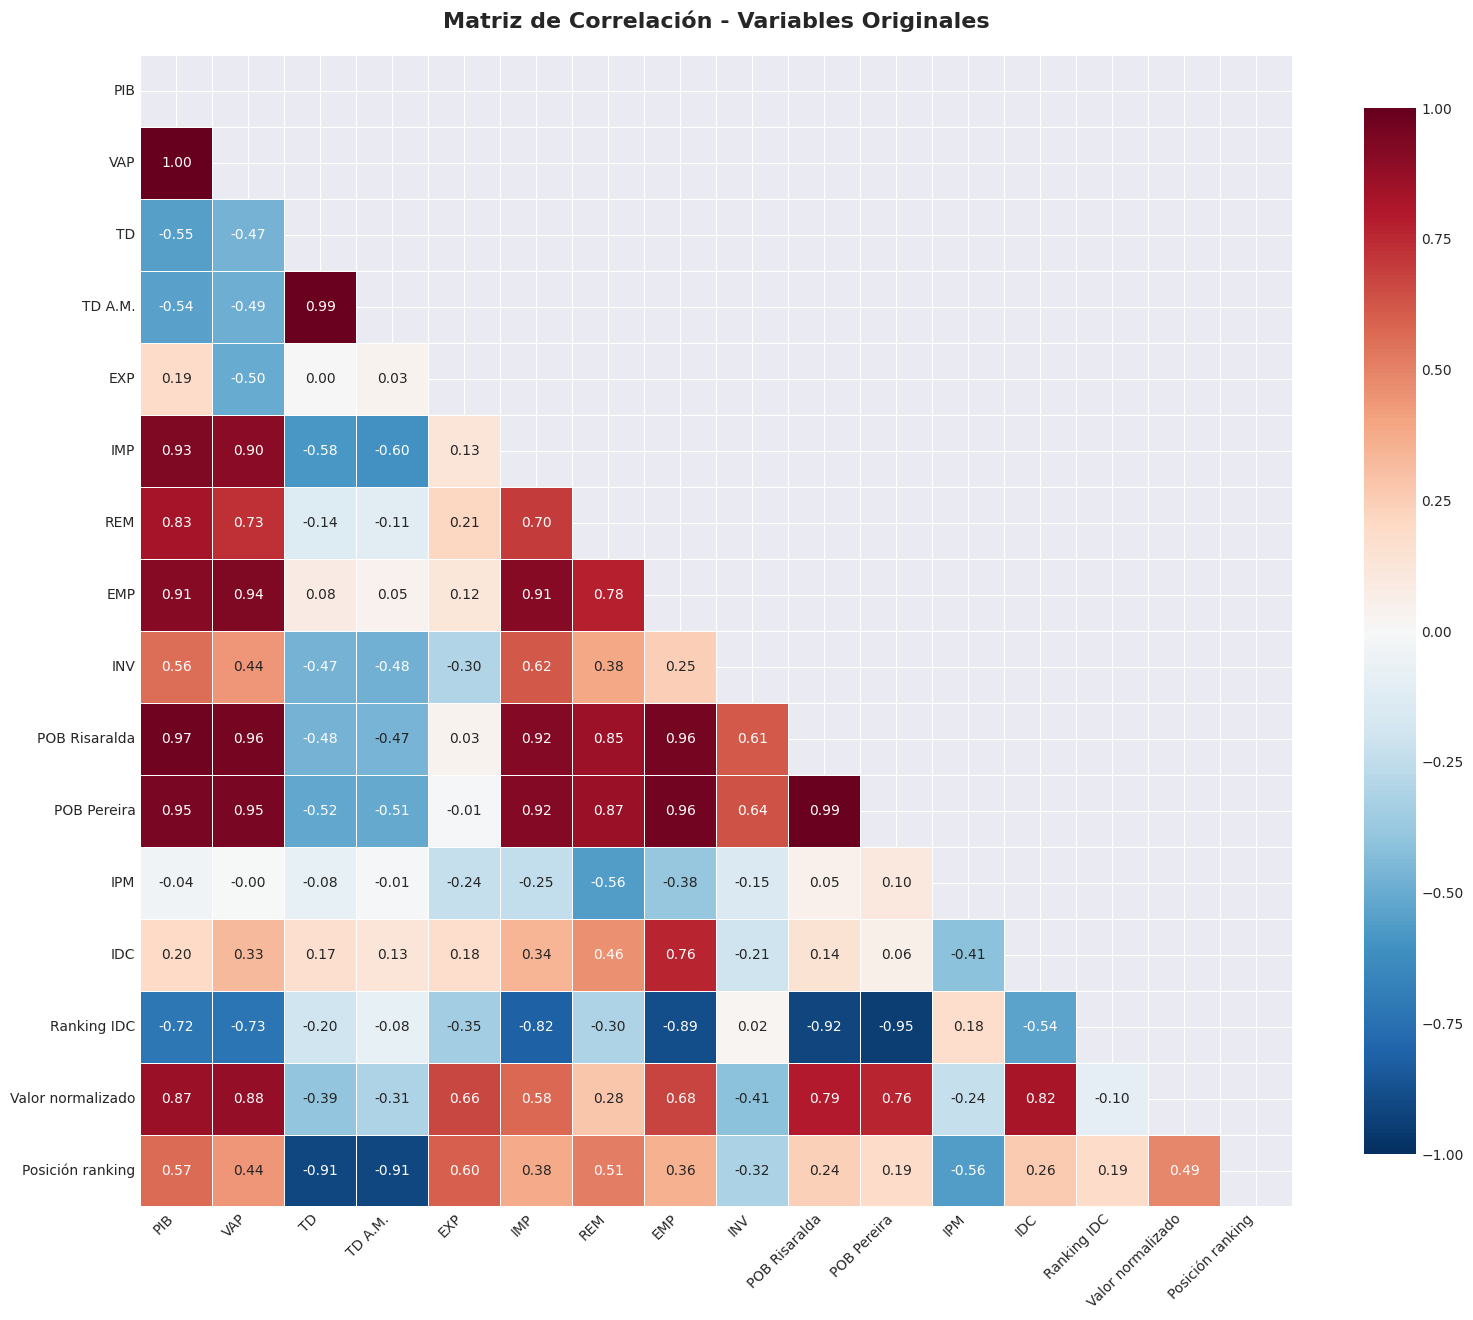


TOP 10 CORRELACIONES MÁS FUERTES (Variables Originales)
PIB                                      ↔ VAP                                        0.998
POB Risaralda                            ↔ POB Pereira                                0.991
TD                                       ↔ TD A.M.                                    0.988
PIB                                      ↔ POB Risaralda                              0.974
EMP                                      ↔ POB Pereira                                0.964
VAP                                      ↔ POB Risaralda                              0.959
EMP                                      ↔ POB Risaralda                              0.956
PIB                                      ↔ POB Pereira                                0.952
VAP                                      ↔ POB Pereira                                0.952
POB Pereira                              ↔ Ranking IDC                               -0.946


In [176]:
# Seleccionar solo variables originales (sin transformaciones ln_ o delta_)
original_vars = [col for col in data.columns[1:] if not col.startswith('ln_') and not col.startswith('delta_')]
data_original = data[original_vars]

# Calcular matriz de correlación
corr_original = data_original.corr()

# Crear figura con heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_original, dtype=bool))  # Máscara para triángulo superior

sns.heatmap(
    corr_original,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlación - Variables Originales', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Mostrar correlaciones más fuertes (excluyendo diagonal)
print("\n" + "=" * 80)
print("TOP 10 CORRELACIONES MÁS FUERTES (Variables Originales)")
print("=" * 80)

# Obtener pares de correlación sin repetir
corr_pairs = []
for i in range(len(corr_original.columns)):
    for j in range(i+1, len(corr_original.columns)):
        if not pd.isna(corr_original.iloc[i, j]):
            corr_pairs.append({
                'Variable 1': corr_original.columns[i],
                'Variable 2': corr_original.columns[j],
                'Correlación': corr_original.iloc[i, j]
            })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlación', key=abs, ascending=False).head(10)
for idx, row in corr_df.iterrows():
    var1 = row['Variable 1'][:40]
    var2 = row['Variable 2'][:40]
    corr_val = row['Correlación']
    print(f"{var1:<40} ↔ {var2:<40} {corr_val:>7.3f}")

#### 1.2.2 Correlación de Variables en Logaritmos

Las transformaciones logarítmicas suavizan la distribución de variables con gran variabilidad y permiten interpretar las relaciones como elasticidades.

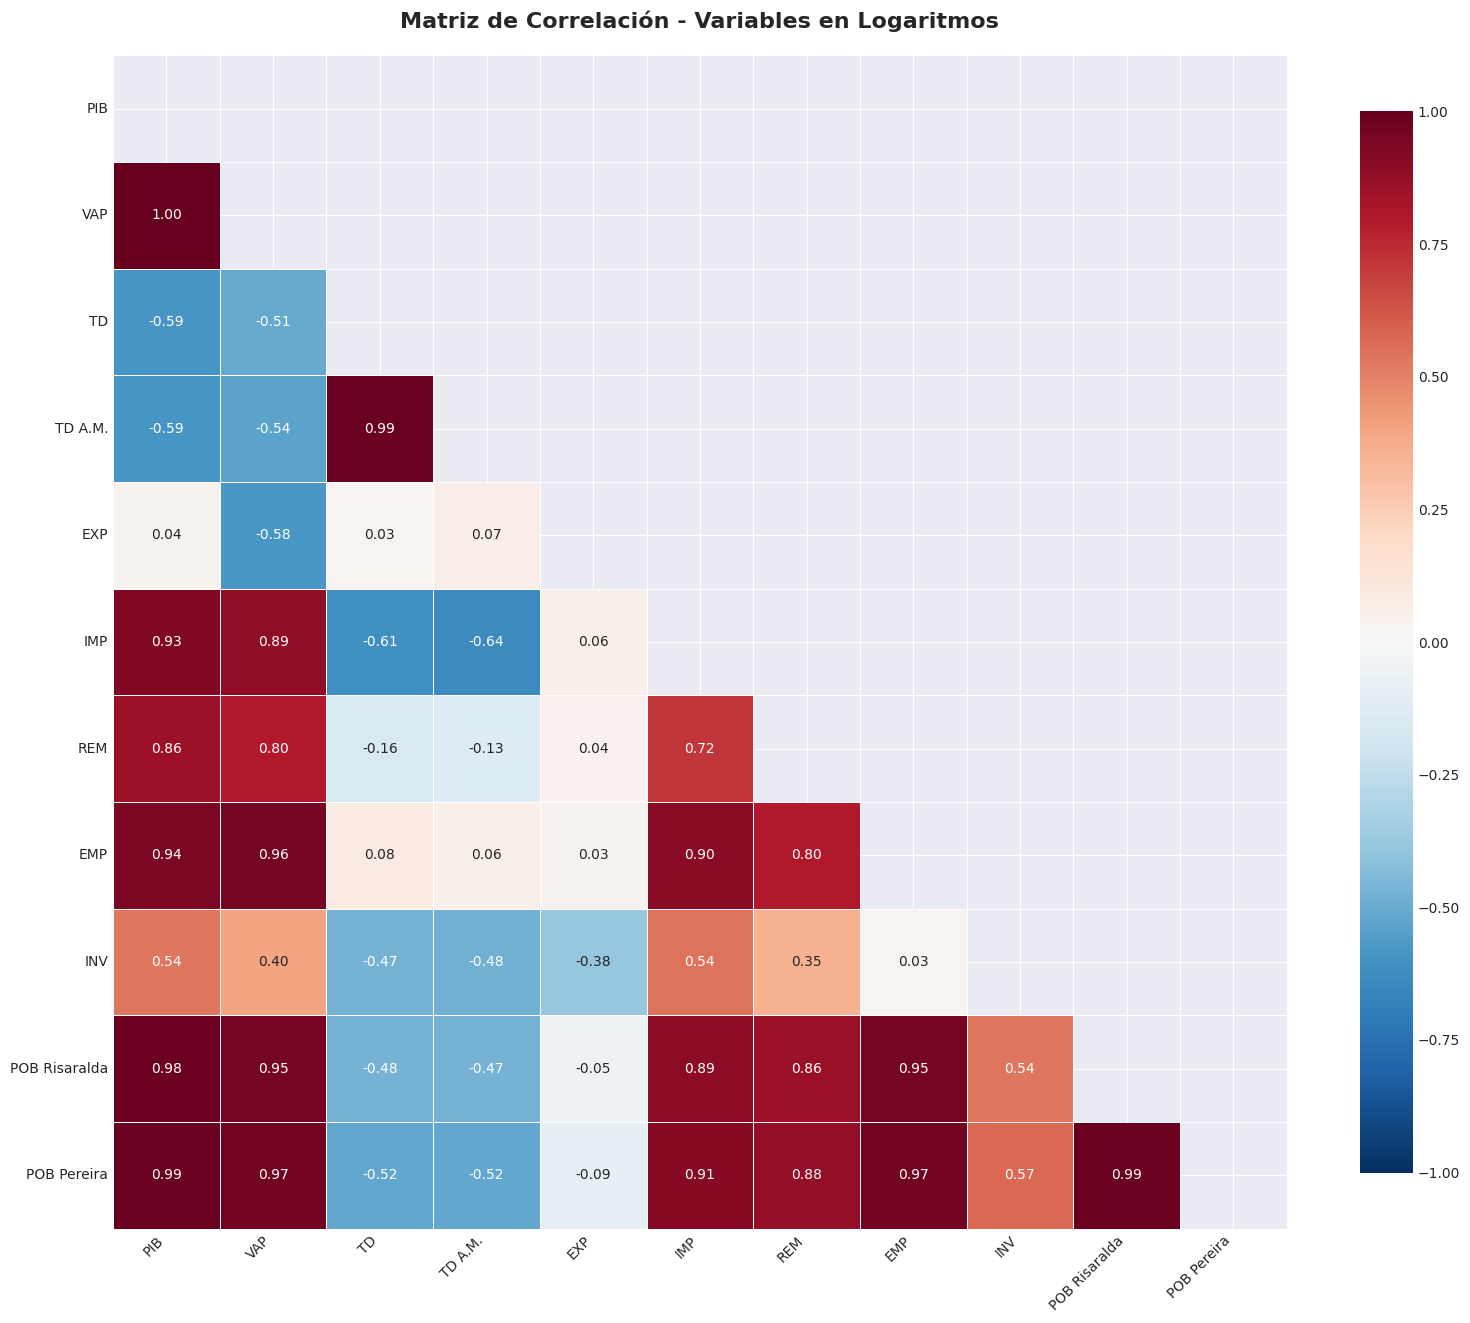


TOP 10 CORRELACIONES MÁS FUERTES (Variables en Logaritmos)
ln_PIB                                   ↔ ln_VAP                                     0.998
ln_POB Risaralda                         ↔ ln_POB Pereira                             0.991
ln_TD                                    ↔ ln_TD A.M.                                 0.989
ln_PIB                                   ↔ ln_POB Pereira                             0.988
ln_PIB                                   ↔ ln_POB Risaralda                           0.982
ln_VAP                                   ↔ ln_POB Pereira                             0.967
ln_EMP                                   ↔ ln_POB Pereira                             0.965
ln_VAP                                   ↔ ln_EMP                                     0.958
ln_VAP                                   ↔ ln_POB Risaralda                           0.955
ln_EMP                                   ↔ ln_POB Risaralda                           0.954


In [177]:
# Seleccionar solo variables en logaritmos (ln_)
ln_vars = [col for col in data.columns if col.startswith('ln_')]
data_ln = data[ln_vars]

# Calcular matriz de correlación
corr_ln = data_ln.corr()

# Crear figura con heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_ln, dtype=bool))

# Nombres simplificados para mejor legibilidad
simplified_names = [col.replace('ln_', '').replace(' (miles de millones de pesos)', '')
                   .replace(' (dólares FOB)', '').replace(' (dólares CIF)', '')
                   .replace(' (millones de dólares)', '').replace(' (millones de pesos)', '')
                   [:40] for col in corr_ln.columns]

corr_ln_display = corr_ln.copy()
corr_ln_display.columns = simplified_names
corr_ln_display.index = simplified_names

sns.heatmap(
    corr_ln_display,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlación - Variables en Logaritmos', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Mostrar correlaciones más fuertes
print("\n" + "=" * 80)
print("TOP 10 CORRELACIONES MÁS FUERTES (Variables en Logaritmos)")
print("=" * 80)

corr_pairs_ln = []
for i in range(len(corr_ln.columns)):
    for j in range(i+1, len(corr_ln.columns)):
        if not pd.isna(corr_ln.iloc[i, j]):
            corr_pairs_ln.append({
                'Variable 1': corr_ln.columns[i].replace('ln_', ''),
                'Variable 2': corr_ln.columns[j].replace('ln_', ''),
                'Correlación': corr_ln.iloc[i, j]
            })

corr_df_ln = pd.DataFrame(corr_pairs_ln).sort_values('Correlación', key=abs, ascending=False).head(10)
for idx, row in corr_df_ln.iterrows():
    var1 = row['Variable 1'][:40]
    var2 = row['Variable 2'][:40]
    corr_val = row['Correlación']
    print(f"ln_{var1:<37} ↔ ln_{var2:<37} {corr_val:>7.3f}")

#### 1.2.3 Correlación de Tasas de Cambio (Diferencias Logarítmicas)

Las diferencias logarítmicas representan tasas de crecimiento aproximadas y permiten analizar cómo los cambios en una variable se relacionan con cambios en otra, eliminando tendencias comunes.

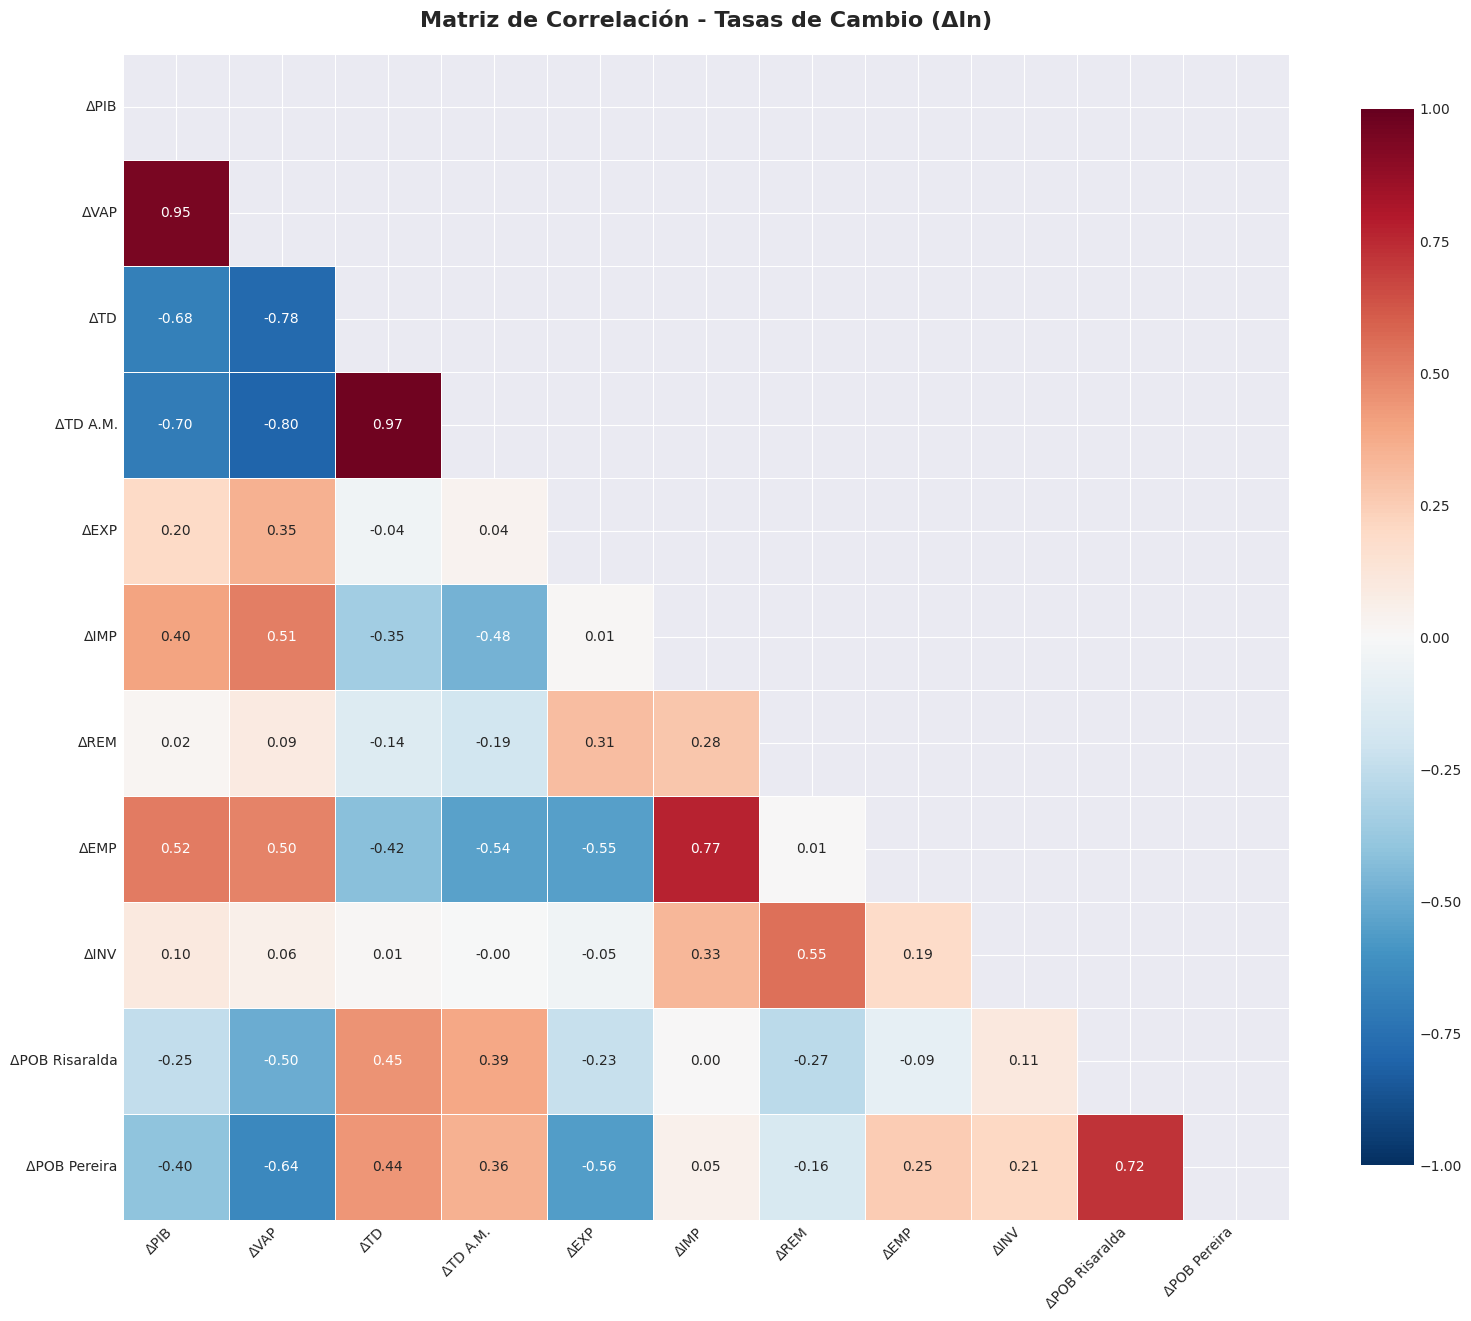


TOP 10 CORRELACIONES MÁS FUERTES (Tasas de Cambio)
ΔTD                                 ↔ ΔTD A.M.                              0.971
ΔPIB                                ↔ ΔVAP                                  0.952
ΔVAP                                ↔ ΔTD A.M.                             -0.801
ΔVAP                                ↔ ΔTD                                  -0.779
ΔIMP                                ↔ ΔEMP                                  0.770
ΔPOB Risaralda                      ↔ ΔPOB Pereira                          0.723
ΔPIB                                ↔ ΔTD A.M.                             -0.697
ΔPIB                                ↔ ΔTD                                  -0.682
ΔVAP                                ↔ ΔPOB Pereira                         -0.644
ΔEXP                                ↔ ΔPOB Pereira                         -0.561


In [178]:
# Seleccionar solo variables delta (tasas de cambio)
delta_vars = [col for col in data.columns if col.startswith('delta_')]
data_delta = data[delta_vars]

# Calcular matriz de correlación
corr_delta = data_delta.corr()

# Crear figura con heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_delta, dtype=bool))

# Nombres simplificados
simplified_names_delta = [col.replace('delta_ln_', 'Δ').replace(' (miles de millones de pesos)', '')
                         .replace(' (dólares FOB)', '').replace(' (dólares CIF)', '')
                         .replace(' (millones de dólares)', '').replace(' (millones de pesos)', '')
                         [:40] for col in corr_delta.columns]

corr_delta_display = corr_delta.copy()
corr_delta_display.columns = simplified_names_delta
corr_delta_display.index = simplified_names_delta

sns.heatmap(
    corr_delta_display,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlación - Tasas de Cambio (Δln)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Mostrar correlaciones más fuertes
print("\n" + "=" * 80)
print("TOP 10 CORRELACIONES MÁS FUERTES (Tasas de Cambio)")
print("=" * 80)

corr_pairs_delta = []
for i in range(len(corr_delta.columns)):
    for j in range(i+1, len(corr_delta.columns)):
        if not pd.isna(corr_delta.iloc[i, j]):
            corr_pairs_delta.append({
                'Variable 1': corr_delta.columns[i].replace('delta_ln_', ''),
                'Variable 2': corr_delta.columns[j].replace('delta_ln_', ''),
                'Correlación': corr_delta.iloc[i, j]
            })

corr_df_delta = pd.DataFrame(corr_pairs_delta).sort_values('Correlación', key=abs, ascending=False).head(10)
for idx, row in corr_df_delta.iterrows():
    var1 = row['Variable 1'][:35]
    var2 = row['Variable 2'][:35]
    corr_val = row['Correlación']
    print(f"Δ{var1:<34} ↔ Δ{var2:<34} {corr_val:>7.3f}")

#### 1.2.4 Análisis Visual de Correlaciones Principales

Visualización de las relaciones más fuertes entre pares de variables para identificar patrones, outliers y la naturaleza de las asociaciones.

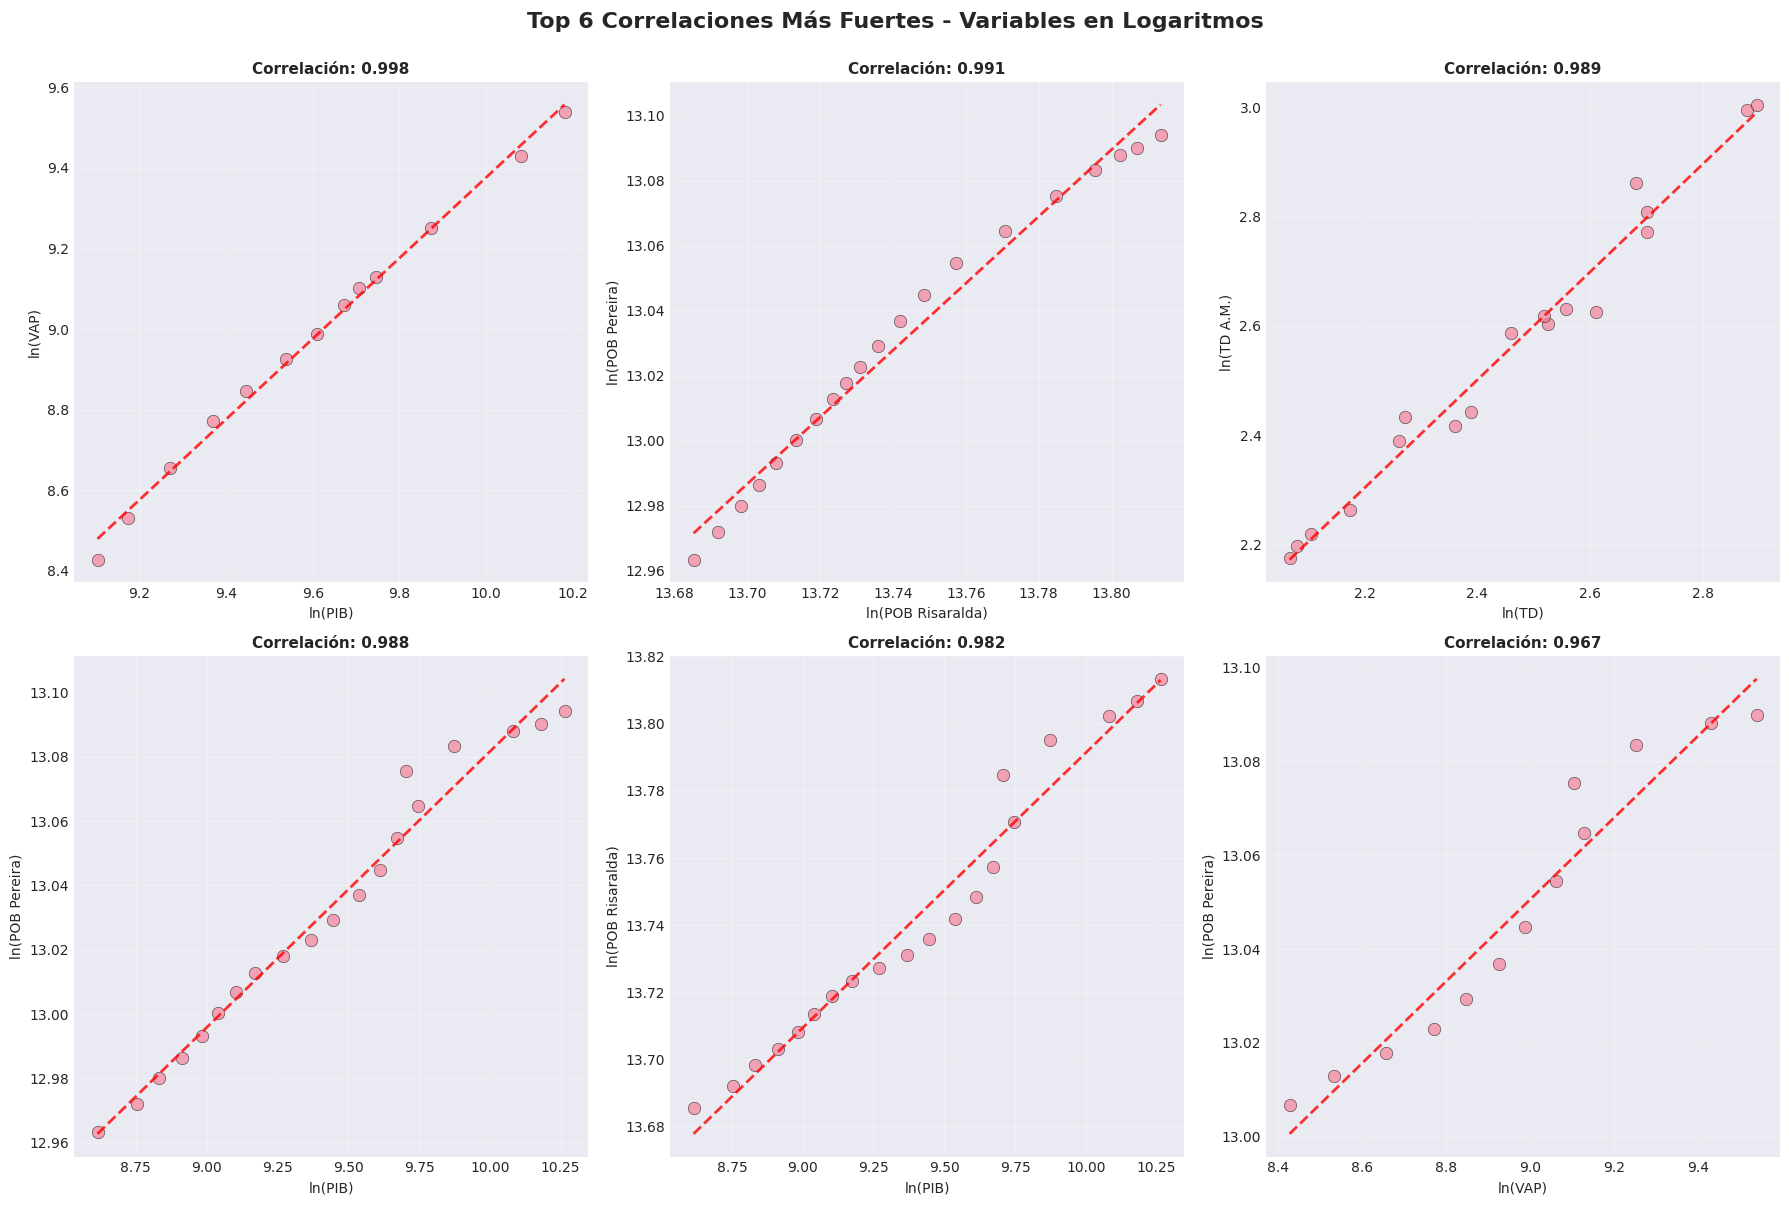

In [179]:
# Seleccionar las 6 correlaciones más fuertes de variables en logaritmos
top_6_pairs = corr_df_ln.head(6)

# Crear subplots para visualizar las relaciones
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (_, row) in enumerate(top_6_pairs.iterrows()):
    var1 = f"ln_{row['Variable 1']}"
    var2 = f"ln_{row['Variable 2']}"
    corr_val = row['Correlación']
    
    # Encontrar la variable original completa
    var1_full = [col for col in data.columns if col == var1][0] if var1 in data.columns else var1
    var2_full = [col for col in data.columns if col == var2][0] if var2 in data.columns else var2
    
    # Gráfico de dispersión
    axes[idx].scatter(data[var1_full], data[var2_full], alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    
    # Línea de regresión
    mask_valid = ~(data[var1_full].isna() | data[var2_full].isna())
    if mask_valid.sum() > 1:
        z = np.polyfit(data[var1_full][mask_valid], data[var2_full][mask_valid], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[var1_full][mask_valid].min(), data[var1_full][mask_valid].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    # Etiquetas y título
    var1_short = row['Variable 1'][:30]
    var2_short = row['Variable 2'][:30]
    axes[idx].set_xlabel(f'ln({var1_short})', fontsize=10)
    axes[idx].set_ylabel(f'ln({var2_short})', fontsize=10)
    axes[idx].set_title(f'Correlación: {corr_val:.3f}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Top 6 Correlaciones Más Fuertes - Variables en Logaritmos', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

#### 1.2.5 Resumen del Análisis de Correlación

Interpretación económica de los principales hallazgos del análisis correlacional.

In [180]:
print("=" * 80)
print("RESUMEN DEL ANÁLISIS DE CORRELACIÓN")
print("=" * 80)

# Estadísticas de correlaciones (variables en logaritmos)
corr_values = []
for i in range(len(corr_ln.columns)):
    for j in range(i+1, len(corr_ln.columns)):
        if not pd.isna(corr_ln.iloc[i, j]):
            corr_values.append(corr_ln.iloc[i, j])

corr_values = np.array(corr_values)

print("\n1. ESTADÍSTICAS GENERALES (Variables en Logaritmos):")
print(f"   - Número de pares de variables: {len(corr_values)}")
print(f"   - Correlación promedio: {corr_values.mean():.3f}")
print(f"   - Correlación máxima: {corr_values.max():.3f}")
print(f"   - Correlación mínima: {corr_values.min():.3f}")
print(f"   - Desviación estándar: {corr_values.std():.3f}")

# Clasificar correlaciones por intensidad
strong_positive = np.sum(corr_values > 0.7)
moderate_positive = np.sum((corr_values > 0.3) & (corr_values <= 0.7))
weak = np.sum((corr_values >= -0.3) & (corr_values <= 0.3))
moderate_negative = np.sum((corr_values < -0.3) & (corr_values >= -0.7))
strong_negative = np.sum(corr_values < -0.7)

print("\n2. DISTRIBUCIÓN DE CORRELACIONES:")
print(f"   - Correlación positiva fuerte (> 0.7):     {strong_positive:>3} pares ({strong_positive/len(corr_values)*100:>5.1f}%)")
print(f"   - Correlación positiva moderada (0.3-0.7): {moderate_positive:>3} pares ({moderate_positive/len(corr_values)*100:>5.1f}%)")
print(f"   - Correlación débil (-0.3 a 0.3):          {weak:>3} pares ({weak/len(corr_values)*100:>5.1f}%)")
print(f"   - Correlación negativa moderada (-0.7 a -0.3): {moderate_negative:>3} pares ({moderate_negative/len(corr_values)*100:>5.1f}%)")
print(f"   - Correlación negativa fuerte (< -0.7):    {strong_negative:>3} pares ({strong_negative/len(corr_values)*100:>5.1f}%)")

print("\n3. ALERTAS DE MULTICOLINEALIDAD:")
high_corr = [(corr_df_ln.iloc[i]['Variable 1'], corr_df_ln.iloc[i]['Variable 2'], corr_df_ln.iloc[i]['Correlación']) 
             for i in range(len(corr_df_ln)) if abs(corr_df_ln.iloc[i]['Correlación']) > 0.8]

if high_corr:
    print(f"   ⚠ Se detectaron {len(high_corr)} pares con correlación |r| > 0.8")
    print("   Considerar para análisis de multicolinealidad en modelos de regresión:")
    for var1, var2, corr in high_corr[:5]:
        print(f"   - {var1[:35]:35} ↔ {var2[:35]:35} (r={corr:.3f})")
else:
    print("   ✓ No se detectaron correlaciones problemáticas (|r| > 0.8)")

print("\n4. OBSERVACIONES ECONÓMICAS CLAVE:")
print("   - Las variables de tamaño económico (PIB, Población, Empresas) tienden a estar")
print("     altamente correlacionadas, reflejando el crecimiento económico conjunto.")
print("   - Las tasas de cambio (Δln) muestran correlaciones más débiles que los niveles,")
print("     indicando que los crecimientos relativos son más independientes.")
print("   - La correlación entre variables de comercio exterior (Exportaciones/Importaciones)")
print("     y variables macroeconómicas sugiere la integración de la economía regional.")

print("\n" + "=" * 80)

RESUMEN DEL ANÁLISIS DE CORRELACIÓN

1. ESTADÍSTICAS GENERALES (Variables en Logaritmos):
   - Número de pares de variables: 55
   - Correlación promedio: 0.285
   - Correlación máxima: 0.998
   - Correlación mínima: -0.635
   - Desviación estándar: 0.597

2. DISTRIBUCIÓN DE CORRELACIONES:
   - Correlación positiva fuerte (> 0.7):      22 pares ( 40.0%)
   - Correlación positiva moderada (0.3-0.7):   6 pares ( 10.9%)
   - Correlación débil (-0.3 a 0.3):           13 pares ( 23.6%)
   - Correlación negativa moderada (-0.7 a -0.3):  14 pares ( 25.5%)
   - Correlación negativa fuerte (< -0.7):      0 pares (  0.0%)

3. ALERTAS DE MULTICOLINEALIDAD:
   ⚠ Se detectaron 10 pares con correlación |r| > 0.8
   Considerar para análisis de multicolinealidad en modelos de regresión:
   - PIB                                 ↔ VAP                                 (r=0.998)
   - POB Risaralda                       ↔ POB Pereira                         (r=0.991)
   - TD                                 

#### 1.2.6 Exportar Matrices de Correlación

Guardamos las matrices de correlación para uso posterior en modelado econométrico.

In [181]:
# Exportar matrices de correlación
import os

# Crear directorio de salida si no existe
output_dir = './output'
os.makedirs(output_dir, exist_ok=True)

# Exportar correlaciones
corr_original.to_csv(f'{output_dir}/correlation_original_vars.csv')
corr_ln.to_csv(f'{output_dir}/correlation_log_vars.csv')
corr_delta.to_csv(f'{output_dir}/correlation_change_rates.csv')

# Exportar top correlaciones
corr_df.to_csv(f'{output_dir}/top_correlations_original.csv', index=False)
corr_df_ln.to_csv(f'{output_dir}/top_correlations_log.csv', index=False)
corr_df_delta.to_csv(f'{output_dir}/top_correlations_change_rates.csv', index=False)

print("✓ Matrices de correlación exportadas exitosamente:")
print(f"  - {output_dir}/correlation_original_vars.csv")
print(f"  - {output_dir}/correlation_log_vars.csv")
print(f"  - {output_dir}/correlation_change_rates.csv")
print(f"\n✓ Top correlaciones exportadas:")
print(f"  - {output_dir}/top_correlations_original.csv")
print(f"  - {output_dir}/top_correlations_log.csv")
print(f"  - {output_dir}/top_correlations_change_rates.csv")

✓ Matrices de correlación exportadas exitosamente:
  - ./output/correlation_original_vars.csv
  - ./output/correlation_log_vars.csv
  - ./output/correlation_change_rates.csv

✓ Top correlaciones exportadas:
  - ./output/top_correlations_original.csv
  - ./output/top_correlations_log.csv
  - ./output/top_correlations_change_rates.csv


In [182]:
# Exportar el Dataset con las variables transformadas
data.to_csv(f'./data/model_data_transformed.csv', index=False)
print(f"✓ Dataset transformado exportado: {output_dir}/model_data_transformed.csv")

print("\n" + "=" * 80)
print("ANÁLISIS DE CORRELACIÓN COMPLETADO")
print("=" * 80)

✓ Dataset transformado exportado: ./output/model_data_transformed.csv

ANÁLISIS DE CORRELACIÓN COMPLETADO
